In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

# For training improvements
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Control training
from tensorflow.keras.layers import BatchNormalization                # Normalize activations

In [2]:
train_dir = r"C:\Users\hp\Downloads\raw-img"


In [3]:
#Data Load


from tensorflow.keras.preprocessing.image import ImageDataGenerator



train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=128,   # 👈 इथे बदल
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=128,   # 👈 validation साठीही बदल
    class_mode='categorical',
    subset='validation'
)


Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.


In [4]:

#CNN Model बनव
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),#batch mhnje kiti image at time traing sathi
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),#remove negative number and create 0
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),#pratek layer cha op veagl yet te stabl ehot
    Flatten(),#convert 2d into 1 d
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')  # 10 classes # softmax multile class #0 1 sigmoid
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping: stop if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(  #
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model checkpoint: save best model
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model.keras',        # नवीन format मध्ये save कर
    monitor='val_loss',
    save_best_only=True
)



# Train the model
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data),
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10


164/164 [==============================] - 220s 1s/step - loss: 2.0338 - accuracy: 0.2870 - val_loss: 1.7303 - val_accuracy: 0.4180
Epoch 2/10
164/164 [==============================] - 204s 1s/step - loss: 1.6886 - accuracy: 0.4141 - val_loss: 1.4507 - val_accuracy: 0.4910
Epoch 3/10
164/164 [==============================] - 235s 1s/step - loss: 1.5306 - accuracy: 0.4741 - val_loss: 1.3190 - val_accuracy: 0.5468
Epoch 4/10
164/164 [==============================] - 245s 1s/step - loss: 1.4353 - accuracy: 0.5121 - val_loss: 1.2487 - val_accuracy: 0.5692
Epoch 5/10
164/164 [==============================] - 226s 1s/step - loss: 1.3358 - accuracy: 0.5450 - val_loss: 1.1412 - val_accuracy: 0.6068
Epoch 6/10
164/164 [==============================] - 222s 1s/step - loss: 1.2832 - accuracy: 0.5616 - val_loss: 1.1282 - val_accuracy: 0.6107
Epoch 7/10
164/164 [==============================] - 225s 1s/step - loss: 1.2288 - accuracy: 0.5839 - val_loss: 1.1577 - val_accuracy: 0.59

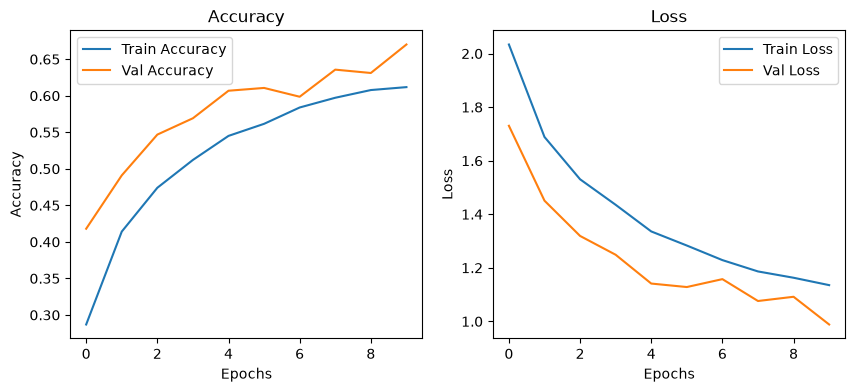

In [6]:
import matplotlib.pyplot as plt

# Plot training results (accuracy & loss)
plt.figure(figsize=(10,4))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [7]:


from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")



import numpy as np
from tensorflow.keras.preprocessing import image

# Path to test image
img_path = r"C:\Users\hp\Downloads\raw-img\scoiattolo\OIP-ugHvCfRkge3BVeRuC571AgHaKD.jpeg"

# Load and preprocess image
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = best_model.predict(img_array)
pred_class = np.argmax(prediction)

# Map predicted index to class name
class_labels = list(train_data.class_indices.keys())
print("Predicted class:", class_labels[pred_class])


1/1 [==============================] - 0s 223ms/step
Predicted class: scoiattolo


In [8]:
loss, acc = best_model.evaluate(val_data)
print(f"Validation Accuracy: {acc*100:.2f}%")


41/41 [==============================] - 42s 994ms/step - loss: 0.9895 - accuracy: 0.6688
Validation Accuracy: 66.88%


In [9]:
from tensorflow.keras.models import load_model

# Save the trained/best model manually
best_model.save("best_model.keras")




In [11]:


# Convert to TFLite with quantization
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("mask_final_quant.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")














INFO:tensorflow:Assets written to: C:\Users\hp\AppData\Local\Temp\tmpxercl4gt\assets


INFO:tensorflow:Assets written to: C:\Users\hp\AppData\Local\Temp\tmpxercl4gt\assets


TFLite model saved successfully!


In [13]:
import os

print("Keras size:",
      os.path.getsize("best_model.keras") / (1024 * 1024), "MB")

print("TFLite size:",
      os.path.getsize("mask_final_quant.tflite") / (1024 * 1024), "MB")




Keras size: 37.876118659973145 MB
TFLite size: 3.1625518798828125 MB
